In [1]:
import sys
!{sys.executable} -m pip install torchdiffeq scipy pandas matplotlib seaborn

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import PharmacokineticUDE
from src.optim import train_ude_alternating

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({"font.size": 12, "figure.dpi": 100})

torch.manual_seed(42)
np.random.seed(42)


In [ ]:
#Se carga el dataset sintético
df = pd.read_csv('../data/synthetic/ddi_synthetic_data.csv')

#Tiempo como un tensor 1D
t_span = torch.tensor(df['time'].values, dtype=torch.float32)

#Observaciones en un tensor de forma [N_puntos, 2]
obs_A = df['obs_A'].values
obs_B = df['obs_B'].values
target_data = torch.tensor(np.stack([obs_A, obs_B], axis=-1), dtype=torch.float32)

#Condición inicial u0
u0 = target_data[0] 

print(f"Forma de target_data: {target_data.shape} -> [Puntos en el tiempo, Cantidad de Drogas]")
print(f"Condición inicial u0: {u0}")

Forma de target_data: torch.Size([30, 2]) -> [Puntos en el tiempo, Cantidad de Drogas]
Condición inicial u0: tensor([107.5166, 145.4473])


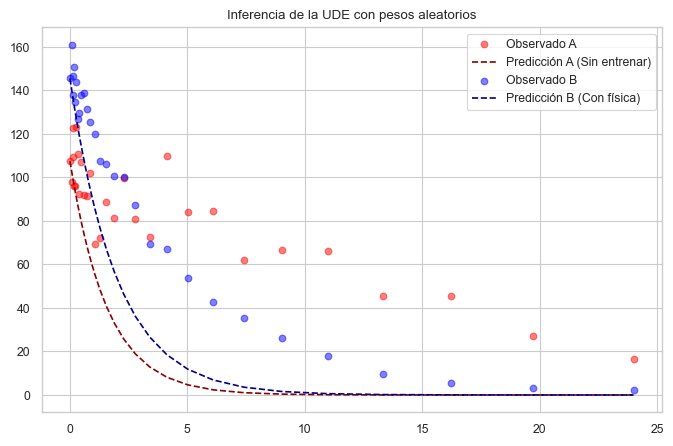

In [ ]:
model = PharmacokineticUDE(hidden_dim=16)

#Se prueba sin entrenamiento
with torch.no_grad():
    pred_init = model(u0, t_span).numpy()

#Se grafican los resultados
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_span.numpy(), obs_A, color='red', label='Observado A', alpha=0.5)
ax.plot(t_span.numpy(), pred_init[:, 0], color='darkred', linestyle='--', label='Predicción A (Sin entrenar)')

ax.scatter(t_span.numpy(), obs_B, color='blue', label='Observado B', alpha=0.5)
ax.plot(t_span.numpy(), pred_init[:, 1], color='darkblue', linestyle='--', label='Predicción B (Con física)')

ax.set_title("Inferencia de la UDE con pesos aleatorios")
ax.legend()
plt.show()